In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

## run simulations


In [2]:
import subprocess
import os

# n_cells_range = [10, 20, 50, 100, 150, 200, 500]  # wide range of values
n_cells_range = range(50, 110, 10)  # more simulations closer to model behavior shift


cmd = ["python", "/Users/ljb80/Projects/perturbo/src/perturbo/_jax_module.py"]
base_args = str.split("--n_control 1000 --n_guides 1 --log2_fc -0.5 --gene_mean 2.0 --gene_disp 10.0 --efficiency 1.0")

for n_cells in n_cells_range:
    output_dir = f"data/run_{n_cells}"
    if os.path.isdir(output_dir):
        continue
    args_new = ["--n_perturbed", str(n_cells), "--output_dir", output_dir]
    args = base_args + args_new
    subprocess.run(cmd + args)

## load results


In [3]:
# for k in ["log2_fold_change", "mean", "dispersion"]:
# k = "log2_fold_change"


def get_simulation_df(data_dir, k):
    """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_df = pd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df

In [4]:
dfs = []
for n_cells in n_cells_range:
    output_dir = f"data/run_{n_cells}"
    lfc_df = get_simulation_df(output_dir, "log2_fold_change")
    dfs.append(lfc_df.assign(n_cells=n_cells))
lfc_all_df = pd.concat(dfs)
lfc_all_df

,log2_fold_change,method,n_cells
0,0.022019,MCMC,50
1,0.068916,MCMC,50
2,0.055404,MCMC,50
3,-0.017619,MCMC,50
4,0.037387,MCMC,50
...,...,...,...
995,-0.088221,SVI,100
996,-0.067785,SVI,100
997,-0.087741,SVI,100
998,-0.084628,SVI,100


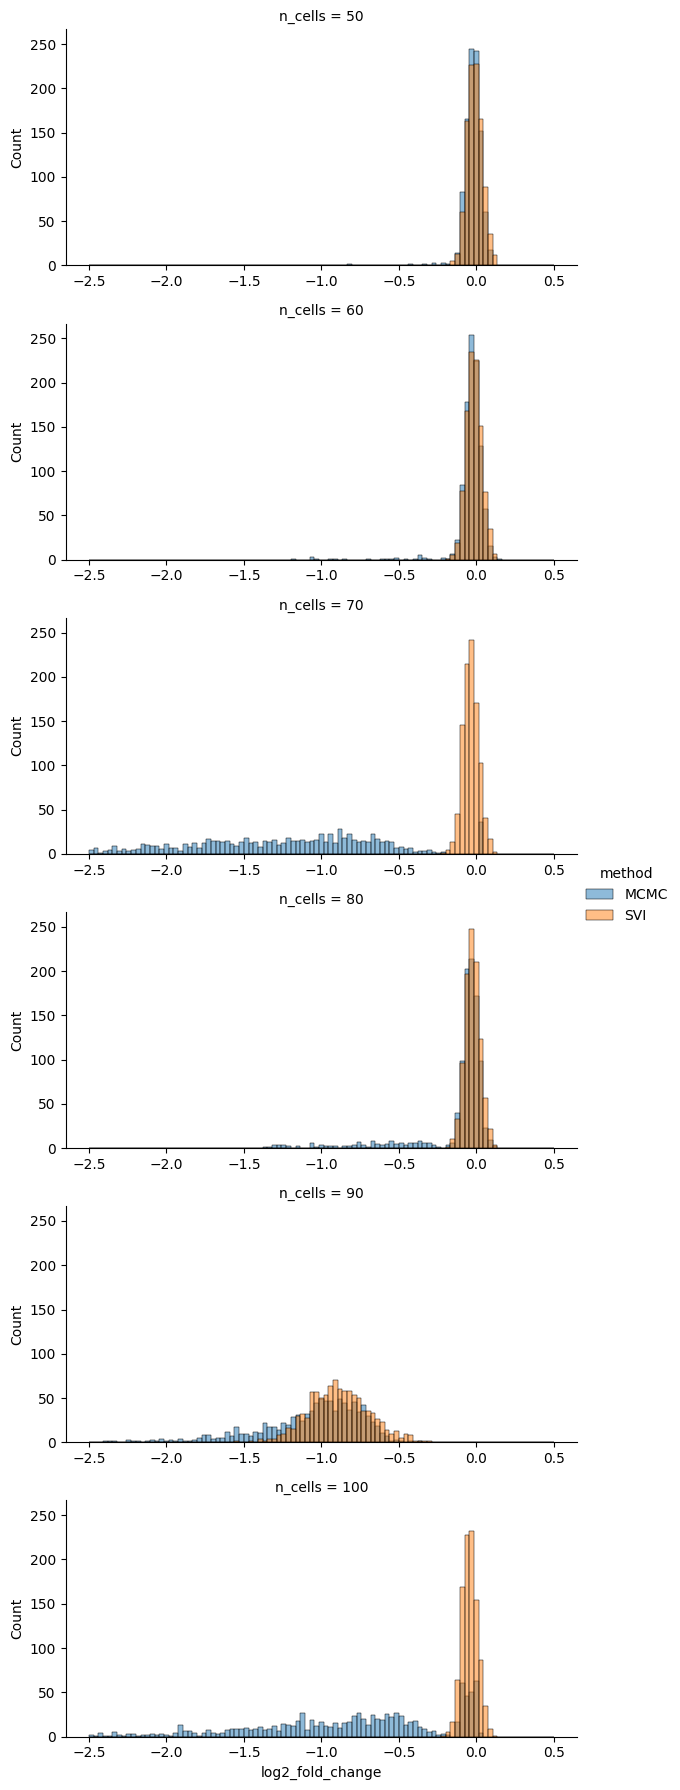

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100

g = sns.FacetGrid(lfc_all_df, row="n_cells", hue="method", height=3, aspect=2, sharex=False)
g.map(sns.histplot, "log2_fold_change", alpha=0.5, bins=np.linspace(-2.5, 0.5, n_bins))
# Add a legend
g.add_legend()

plt.show()

In [6]:
two_sided_threshold = 0.1
lfc_all_df.assign(lfc_significant=lambda x: abs(x["log2_fold_change"]) > two_sided_threshold).groupby(
    ["method", "n_cells"]
)["lfc_significant"].mean()

method  n_cells
MCMC    50         0.045
        60         0.065
        70         0.964
        80         0.196
        90         1.000
        100        0.801
SVI     50         0.046
        60         0.047
        70         0.093
        80         0.061
        90         1.000
        100        0.118
Name: lfc_significant, dtype: float64

In [7]:
one_sided_threshold = -0.1
lfc_all_df.assign(lfc_significant=lambda x: x["log2_fold_change"] < one_sided_threshold).groupby(["method", "n_cells"])[
    "lfc_significant"
].mean()

method  n_cells
MCMC    50         0.045
        60         0.059
        70         0.964
        80         0.194
        90         1.000
        100        0.801
SVI     50         0.025
        60         0.034
        70         0.089
        80         0.056
        90         1.000
        100        0.116
Name: lfc_significant, dtype: float64